In [1]:
import zipfile
import os

zip_file_path = '/content/archive (3).zip'
extract_dir = '/content/extracted_data'

# Create the directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Files extracted to: {extract_dir}")

# List the contents of the extracted directory
print("Contents of the extracted directory:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Files extracted to: /content/extracted_data
Contents of the extracted directory:
/content/extracted_data/CWC2023.csv


In [2]:
import pandas as pd

# Load the dataset
data_path = '/content/extracted_data/CWC2023.csv'
df = pd.read_csv(data_path)

# Display the first few rows of the DataFrame
print("First 5 rows of the dataset:")
print(df.head())

# Display basic information about the DataFrame
print("\nDataFrame Info:")
df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive statistics:")
print(df.describe())

First 5 rows of the dataset:
   Match ID  Match Date Match Time         City                    Stadium  \
0         1  05-10-2023    2:00 PM    Ahmedabad      Narendra Modi Stadium   
1         2  06-10-2023    2:00 PM    Hyderabad               Eden Gardens   
2         3  07-10-2023    2:00 PM  Dharamshala               HPCA Stadium   
3         4  07-10-2023    2:00 PM        Delhi       Arun Jaitley Stadium   
4         5  08-10-2023    2:00 PM      Chennai  M. A. Chidambaram Stadium   

         Team A       Team B  Toss Winner Toss Decision  Score A  ...  \
0       England   NewZealand   NewZealand         Field      282  ...   
1      Pakistan  Netherlands  Netherlands         Field      286  ...   
2   Afghanistan   Bangladesh   Bangladesh         Field      156  ...   
3  South Africa    Sri Lanka    Sri Lanka         Field      428  ...   
4     Australia        India    Australia           Bat      199  ...   

   No Balls B  Penalty B  Extras B   Wining Team     Margin  \


In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical

# Drop irrelevant columns
df_processed = df.drop(columns=[
    'Match ID', 'Match Date', 'Match Time', 'City', 'Stadium', 'Margin',
    'Man of the Match', 'Umpire 1', 'Umpire 2', 'TV Umpire', 'Match Refree'
])

# Identify categorical and numerical features
categorical_features = [
    'Team A', 'Team B', 'Toss Winner', 'Toss Decision'
]
numerical_features = [
    'Score A', 'Wickets A', 'Overs Played A', 'Runrate A', '4s A', '6s A', 'Boundaries A', 'Leg Byes A',
    'Wides A', 'No Balls A', 'Penalty A', 'Extras A',
    'Score B', 'Wickets B', 'Overs Played B', 'Runrate B', '4s B', '6s B', 'Boundaries B', 'Leg Byes B',
    'Wides B', 'No Balls B', 'Penalty B', 'Extras B', 'Maiden Overs A', 'Maiden Overs B', 'Byes A', 'Byes B'
]

# Handle the target variable 'Wining Team'
# Ensure the target variable is of object type for LabelEncoder
df_processed['Wining Team'] = df_processed['Wining Team'].astype(str)
label_encoder = LabelEncoder()
df_processed['Wining Team_encoded'] = label_encoder.fit_transform(df_processed['Wining Team'])

# One-hot encode categorical features
df_processed = pd.get_dummies(df_processed, columns=categorical_features, drop_first=True)

# Select features (X) and target (y)
X = df_processed.drop(columns=['Wining Team', 'Wining Team_encoded'])
y = df_processed['Wining Team_encoded']

# Align columns after one-hot encoding, ensuring consistency in feature sets.
# This is particularly important if some categories appear in training but not test, or vice-versa.
# For a small dataset like this, it's good practice, for larger datasets with more variation it's crucial.
# For now, let's keep all columns that resulted from get_dummies.

# Clean and convert numerical features to ensure they are numeric
for col in numerical_features:
    # Check if the column is currently an object type (string)
    # or if it contains non-numeric values that would cause an error
    if X[col].dtype == 'object' or X[col].astype(str).str.contains(',').any():
        X[col] = X[col].astype(str).str.replace(',', '.', regex=False)
        X[col] = pd.to_numeric(X[col], errors='coerce') # Coerce errors to NaN
        # Fill any NaNs that might have resulted from coercion, e.g., with the mean
        if X[col].isnull().any():
            X[col] = X[col].fillna(X[col].mean())

# Scale numerical features
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert target to one-hot encoding for Keras (if it's multi-class classification)
# Check the number of unique classes
num_classes = len(np.unique(y_train))
if num_classes > 2: # For binary classification, sparse_categorical_crossentropy is usually used with integer labels
    y_train_encoded = to_categorical(y_train, num_classes=num_classes)
    y_test_encoded = to_categorical(y_test, num_classes=num_classes)
else:
    y_train_encoded = y_train
    y_test_encoded = y_test

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train_encoded.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test_encoded.shape)
print("\nFirst 5 rows of preprocessed features (X_train):\n", X_train.head())
print("\nFirst 5 rows of encoded target (y_train_encoded):\n", y_train_encoded[:5])
print("\nNumber of unique winning teams (classes):", num_classes)
print("\nOriginal winning teams and their encoded values:")
for i, team in enumerate(label_encoder.classes_):
    print(f"  {team}: {i}")

Shape of X_train: (38, 56)
Shape of y_train: (38, 10)
Shape of X_test: (10, 56)
Shape of y_test: (10, 10)

First 5 rows of preprocessed features (X_train):
      Score A  Wickets A  Overs Played A  Maiden Overs A      4s A      6s A  \
18 -0.270894   0.876663        0.409495       -0.441652 -1.492583 -0.922846   
32  0.980652  -0.048168        0.529591        1.485556  0.636696  0.222756   
13 -0.969124   0.876663       -0.811483        0.200751 -0.365317 -1.304714   
47 -0.560725   0.876663        0.529591        0.843154 -1.617834 -0.922846   
24 -1.667355   0.876663       -2.833102       -1.084055 -0.866324 -1.304714   

    Boundaries A  Runrate A  Leg Byes A    Byes A  ...  Toss Winner_Australia  \
18     -1.446867  -0.524769   -0.975125  5.235647  ...                  False   
32      0.539876   0.923225   -0.635951  1.769287  ...                  False   
13     -0.842206  -0.888703   -0.975125 -0.397187  ...                  False   
47     -1.533247  -0.888703   -0.296777  1.7

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,202 (63.29 KB)

 Trainable params: 16,202 (63.29 KB)

 Non-trainable params: 0 (0.00 B)


Training Baseline Model...

Evaluating Baseline Model...
Baseline Model Test Loss: 2.3917
Baseline Model Test Accuracy: 0.2000


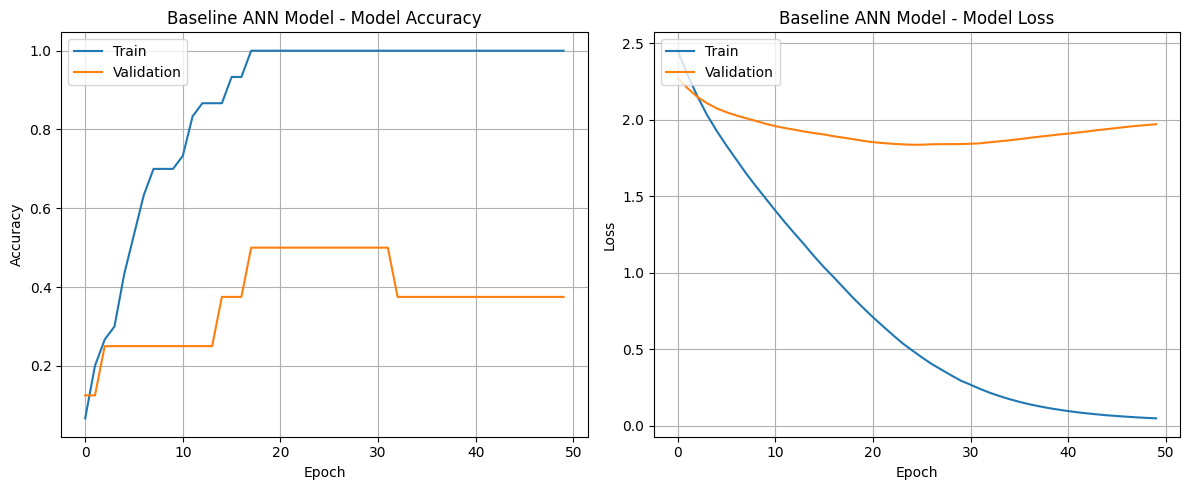

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns

# Get input shape and number of classes
input_shape = X_train.shape[1]
num_classes = y_train_encoded.shape[1]

# --- Baseline ANN Model (without hyperparameter tuning) ---

def build_baseline_model(input_shape, num_classes):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')  # Output layer with softmax for multi-class classification
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

baseline_model = build_baseline_model(input_shape, num_classes)
baseline_model.summary()

print("\nTraining Baseline Model...")
history_baseline = baseline_model.fit(X_train,
                                    y_train_encoded,
                                    epochs=50,  # You can adjust epochs
                                    batch_size=16,
                                    validation_split=0.2, # Use a small portion of training data for validation
                                    verbose=0) # Set verbose to 1 to see progress

print("\nEvaluating Baseline Model...")
loss_baseline, accuracy_baseline = baseline_model.evaluate(X_test, y_test_encoded, verbose=0)
print(f"Baseline Model Test Loss: {loss_baseline:.4f}")
print(f"Baseline Model Test Accuracy: {accuracy_baseline:.4f}")

# --- Plotting function for training history ---

def plot_training_history(history, title):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{title} - Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid(True)

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{title} - Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plot baseline model training history
plot_training_history(history_baseline, 'Baseline ANN Model')

In [7]:
# Install Keras Tuner
!pip install keras-tuner -q
import keras_tuner as kt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.8 MB/s eta 0:00:00


### Hyperparameter Tuning with Keras Tuner

Now, let's perform hyperparameter tuning using `keras-tuner` to find a better architecture for our ANN. We will tune the number of layers, the number of units in each layer, and the learning rate.

In [12]:
def build_tuned_model(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units_input', min_value=64, max_value=256, step=32),
                    activation='relu',
                    input_shape=(input_shape,)))

    # Tune the number of hidden layers and units in each hidden layer
    for i in range(hp.Int('num_hidden_layers', 1, 3)):
        model.add(Dense(units=hp.Int(f'units_hidden_{i}', min_value=32, max_value=128, step=32),
                        activation='relu'))

    model.add(Dense(num_classes, activation='softmax'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=Adam(learning_rate=hp_learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_tuned_model,
    objective='val_accuracy',
    max_trials=10,  # Number of different hyperparameter combinations to try
    executions_per_trial=2, # Number of models to train for each trial (to reduce variance)
    directory='keras_tuner_dir', # Directory to store results
    project_name='ann_tuning')

print("\nSearching for best hyperparameters...")
tuner.search(X_train, y_train_encoded, epochs=50, validation_split=0.2, verbose=0)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\nOptimal number of units in the input layer: {best_hps.get('units_input')}")
print(f"Optimal number of hidden layers: {best_hps.get('num_hidden_layers')}")
for i in range(best_hps.get('num_hidden_layers')):
    print(f"Optimal number of units in hidden layer {i}: {best_hps.get(f'units_hidden_{i}')}")
print(f"Optimal learning rate: {best_hps.get('learning_rate')}")

# Build the model with the optimal hyperparameters and train it
model_tuned = tuner.hypermodel.build(best_hps)

print("\nTraining Tuned Model...")
history_tuned = model_tuned.fit(X_train, y_train_encoded, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

print("\nEvaluating Tuned Model...")
loss_tuned, accuracy_tuned = model_tuned.evaluate(X_test, y_test_encoded, verbose=0)
print(f"Tuned Model Test Loss: {loss_tuned:.4f}")
print(f"Tuned Model Test Accuracy: {accuracy_tuned:.4f}")

Reloading Tuner from keras_tuner_dir/ann_tuning/tuner0.json

Searching for best hyperparameters...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Optimal number of units in the input layer: 160
Optimal number of hidden layers: 3
Optimal number of units in hidden layer 0: 32
Optimal number of units in hidden layer 1: 96
Optimal number of units in hidden layer 2: 32
Optimal learning rate: 0.01

Training Tuned Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Evaluating Tuned Model...
Tuned Model Test Loss: 17.5876
Tuned Model Test Accuracy: 0.2000


### Visual Comparison: Baseline vs. Hyperparameter-Tuned Model

Here are the training histories for both the baseline model and the hyperparameter-tuned model. This will allow us to visually compare their learning curves and performance.

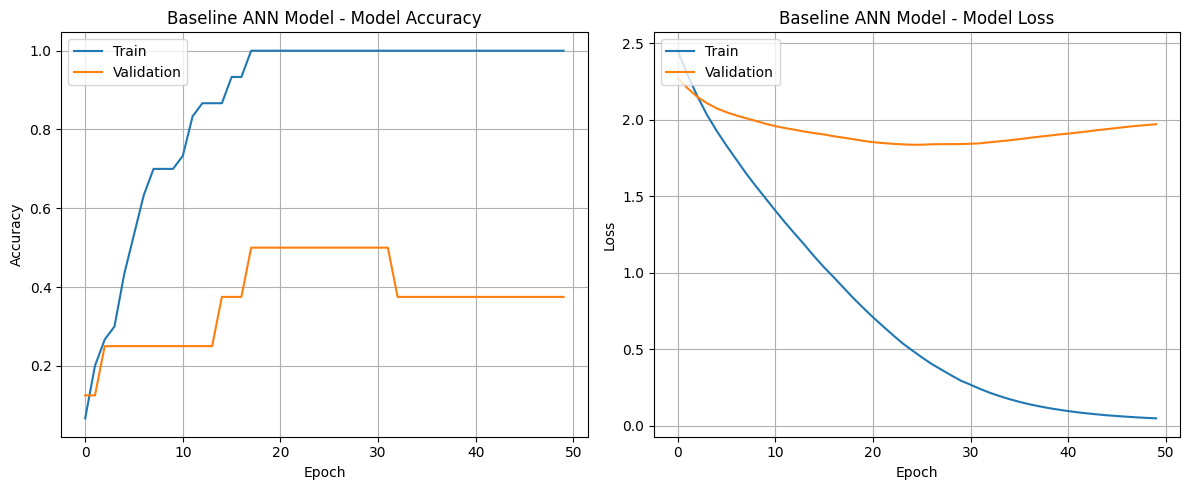

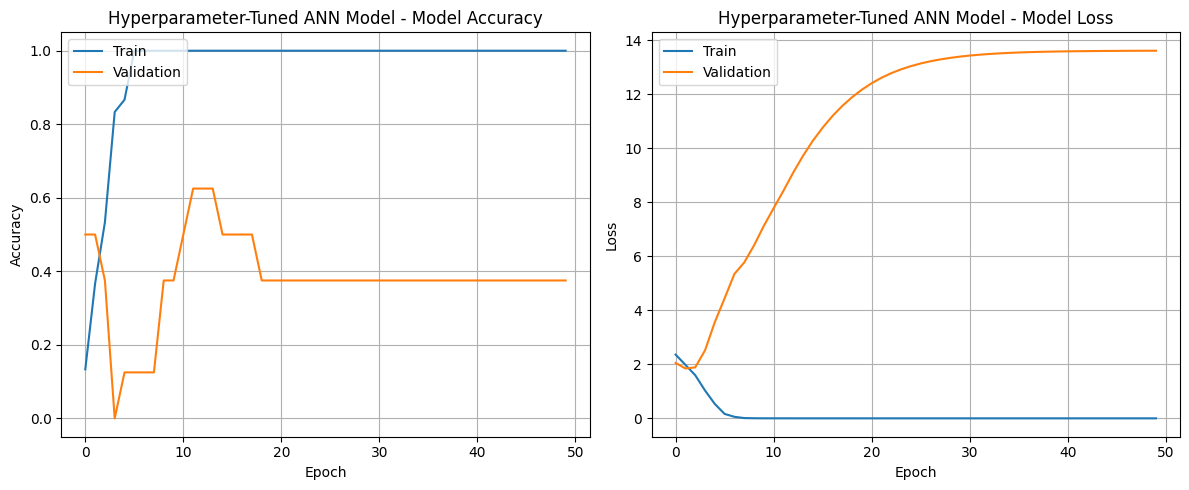

In [13]:
# Plot training history for both models for comparison

# Reusing the plot_training_history function defined earlier
plot_training_history(history_baseline, 'Baseline ANN Model')
plot_training_history(history_tuned, 'Hyperparameter-Tuned ANN Model')